对于任意KL估计器，其**期望梯度**可以<font color='red'>分解为两部分</font>：

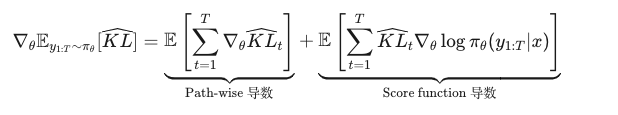

In [7]:
Image(filename='estimator.png')

# "Path-wise"（路径式/路径梯度）
- <font color='red'>是与 Score Function（得分函数）相对的一种梯度估计方法</font>
- 主要用于可重参数化（reparameterizable）的分布。

## 两种梯度估计方法对比

|            | **Path-wise**（路径式）       | **Score Function**（得分函数）           |
| ---------- | ------------------------ | ---------------------------------- |
| **别名**     | Reparameterization trick | Likelihood ratio trick / REINFORCE |
| **适用条件**   | 分布可重参数化                  | 任何分布                               |
| **梯度形式**   | 直接对采样路径求导                | 对数概率梯度 × 奖励                        |
| **方差**     | 通常更低                     | 通常更高                               |
| **是否需要可微** | 需要（通过采样路径）               | 不需要                                |


## 重参数化

- 重参数化是**将一个随机变量表示为确定性函数 + 独立噪声的技术**。


In [2]:
from IPython.display import Image

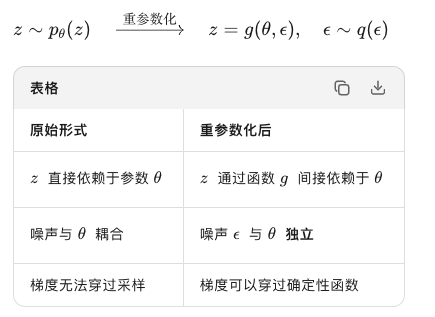

In [3]:
Image(filename='./Reparameterization.png')

### 经典例子：正态分布

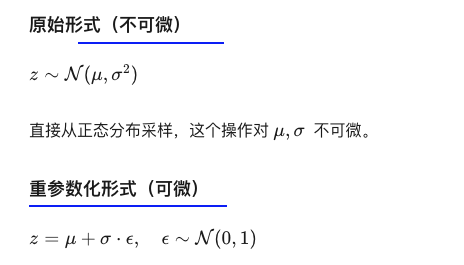

In [4]:
Image(filename='./zhengtai.png')

In [ ]:
原始采样：              重参数化后：
┌─────────────┐        ┌─────────────────────┐
│  μ, σ       │        │   μ, σ      ε~N(0,1) │
│   ↓         │        │    ↓          ↓      │
│ z~N(μ,σ²)   │   →    │ z = μ + σ·ε          │
│   ↓         │        │    ↓                 │
│  f(z)       │        │   f(z)               │
└─────────────┘        └─────────────────────┘
   ↑                        ↑
 不可微                    可微！

#### 关键：
- ϵ  是从标准正态分布采样的，不依赖于 μ,σ 。
- 梯度可以沿着 μ+σ⋅ϵ  这条"路径"反向传播。

### 为什么叫"Path-wise"？
因为梯度沿着采样路径 z=g(θ,ϵ)  传播：

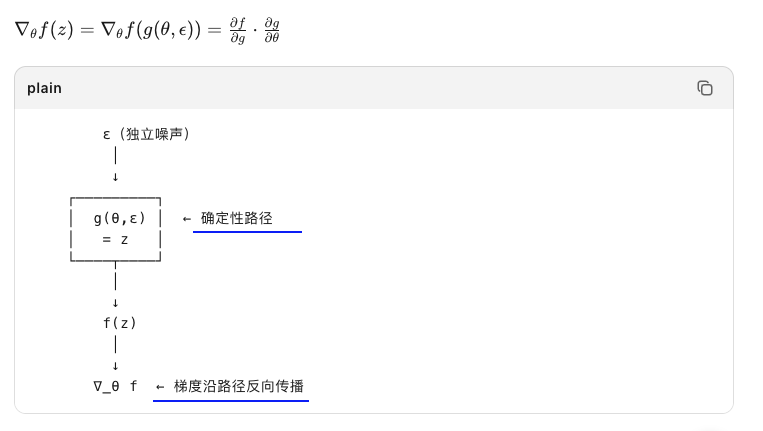

In [5]:
Image(filename='./why_path.png')

### 在 VAE 中的应用
变分自编码器（VAE）<font color='red'>是重参数化最著名的应用</font>：

| 组件   | 作用                                |
| ---- | --------------------------------- |
| 编码器  | 输出 $\mu, \sigma$（潜在变量的均值和方差）      |
| 重参数化 | $z = \mu + \sigma \cdot \epsilon$ |
| 解码器  | 从 $z$ 重建输入                        |


- 没有重参数化：从 $N(μ,σ^2)$  采样是随机操作，梯度无法从解码器传回编码器。
- **有重参数化**：采样变为确定性操作，梯度可以顺利反向传播。

### 一句话总结
- 重参数化是"把随机性外包给独立噪声，让参数到样本之间变成确定性路径"的技术。
- 这样梯度就能沿着这条路径反向传播，实现对期望的梯度估计。
- 它是 VAE 等连续模型训练的核心，但在 LLM 的离散采样中需要近似或改用 Score Function。

### 与 Score Function 的对比

|            | **Path-wise（重参数化）**                                                                 | **Score Function**                                                                       |
| ---------- | ----------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **公式**     | $\nabla_\theta \mathbb{E}[f(z)] = \mathbb{E}[\nabla_\theta f(g(\theta, \epsilon))]$ | $\nabla_\theta \mathbb{E}[f(z)] = \mathbb{E}[f(z) \cdot \nabla_\theta \log p_\theta(z)]$ |
| **是否需要可微** | 需要 $f$ 和 $g$ 可微                                                                     | 不需要                                                                                      |
| **方差**     | 通常更低                                                                                | 通常更高                                                                                     |
| **适用范围**   | 连续分布、可重参数化分布                                                                        | 任何分布（包括离散）                                                                               |
| **LLM适用性** | 有限（离散采样不可微）                                                                         | 通用（REINFORCE/GRPO）                                                                       |


## 为什么 LLM 通常不用 Path-wise？
- 在 LLM / 离散分布中的特殊性

| 问题                   | 说明                                                            |
| -------------------- | ------------------------------------------------------------- |
| **采样不可微**            | $y \sim \text{Categorical}(\pi_\theta)$ 的 argmax/sample 操作不可微 |
| **Gumbel-Softmax**   | 可以用连续近似，但引入偏差                                                 |
| **Straight-through** | 前向用 sample，反向用 softmax 梯度，也是近似                                |


### LLM 中的"Path-wise"含义
- 在《A Comedy of Estimators》论文中，**"Path-wise"指的是直接对 KL 估计器本身求导（不通过 score function）：**

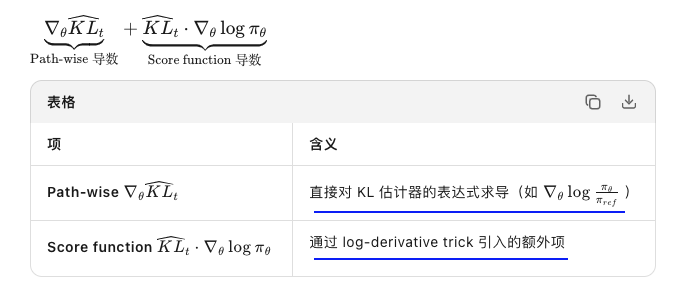

In [6]:
Image(filename='./pw.png')

### 对比总结



In [ ]:
┌─────────────────────────────────────────────────────────────┐
│                    梯度估计方法谱系                           │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│   Path-wise（重参数化）        Score Function（似然比）        │
│        ↓                           ↓                        │
│   z = g(θ, ε)                 ∇_θ log π_θ(y)               │
│        ↓                           ↓                        │
│   直接求导 ∇_θ f(z)            f(y) · ∇_θ log π_θ(y)       │
│        ↓                           ↓                        │
│   需要：可重参数化               需要：无（通用）              │
│   优点：低方差                   优点：通用性强               │
│   缺点：适用性受限               缺点：高方差                 │
│                                                             │
│   LLM 离散采样：通常只能用 Score Function                  │
│   但分析梯度时，仍区分 Path-wise 和 Score 两项               │
│                                                             │
└─────────────────────────────────────────────────────────────┘